<a href="https://www.kaggle.com/code/ameythakur20/customer-churn-pseudo-labeled-xgboost-ensemble" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Customer Churn Prediction: Pseudo-Labeled XGBoost Ensemble

**Playground Series - Season 6 Episode 3**

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

This notebook presents a technical framework for predicting customer churn within a telecommunications dataset. The methodology combines domain-driven feature engineering, leakage-free Target Encoding (TE), multi-seed XGBoost cross-validation, and iterative Pseudo Labeling. The objective is to maximize the Area Under the Receiver Operating Characteristic Curve (ROC AUC).

### Abstract
The primary objective of this study is to develop a robust classification pipeline for the Predict Customer Churn competition. By engineering higher-order interactions, applying nested cross-validation encoding, and leveraging semi-supervised pseudo labeling, the model captures subtle behavioral patterns while maintaining numerical stability. The following sections detail the data ingestion, feature synthesis, model training, and evaluation techniques employed.

**Outline:**

1. [Library Initialization and Configuration](#1-library-initialization-and-configuration)
2. [Data Acquisition and Domain Information](#2-data-acquisition-and-domain-information)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Methodology: Advanced Feature Engineering](#4-methodology-advanced-feature-engineering)
5. [Encoding Strategies and Leakage Prevention](#5-encoding-strategies-and-leakage-prevention)
6. [Model Architecture: Multi-Seed XGBoost](#6-model-architecture-multi-seed-xgboost)
7. [Pseudo Labeling](#7-pseudo-labeling)
8. [Evaluation and Statistical Analysis](#8-evaluation-and-statistical-analysis)
9. [Inference and Results Documentation](#9-inference-and-results-documentation)
10. [Conclusion and Results Summary](#10-conclusion-and-results-summary)

---


# 1. Library Initialization and Configuration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

# Suppress warnings and expand display width
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


In [2]:
class CFG:
    """Centralized configuration for reproducibility."""
    seed       = 42
    n_folds    = 10
    inner_folds = 5
    target     = 'Churn'
    gpu        = True

    # Seeds used to average predictions and reduce variance
    seeds = [42, 2024, 2025, 7, 13]

    # Pseudo labeling parameters
    pl_threshold = 0.985   # confidence cutoff
    pl_rounds    = 2       # number of relabeling passes

    # Categorical columns used for interaction features
    top_cats = [
        'Contract', 'InternetService', 'PaymentMethod',
        'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
    ]


def seed_everything(seed):
    """Sets the random state for numpy and the Python hash seed."""
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(CFG.seed)

print("Configuration loaded.")
print(f"  Folds: {CFG.n_folds}, Seeds: {CFG.seeds}")
print(f"  Pseudo labeling rounds: {CFG.pl_rounds}, threshold: {CFG.pl_threshold}")


Configuration loaded.
  Folds: 10, Seeds: [42, 2024, 2025, 7, 13]
  Pseudo labeling rounds: 2, threshold: 0.985


# 2. Data Acquisition and Domain Information


The competition dataset contains customer records from a telecommunications provider. Each row represents a single customer, and the target column indicates whether the customer has churned.

We also load the original Telco Customer Churn dataset (when available) and append it to the training set. This provides additional real-world observations that can improve generalization.


In [3]:
# Resolve the base directory depending on runtime environment
input_paths = [
    '/kaggle/input/playground-series-s6e3/',
    '/kaggle/input/competitions/playground-series-s6e3/',
    ''  # local fallback
]

base_dir = next(
    (p for p in input_paths if os.path.exists(os.path.join(p, 'train.csv'))),
    ''
)

train = pd.read_csv(os.path.join(base_dir, 'train.csv'))
test  = pd.read_csv(os.path.join(base_dir, 'test.csv'))

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")


Train shape: (594194, 21)
Test shape:  (254655, 20)


In [4]:
# Search for the original Telco dataset across Kaggle input directories
orig_dir = ''
if os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'WA_Fn-UseC_-Telco-Customer-Churn.csv' in files:
            orig_dir = root
            break

orig_path = os.path.join(orig_dir, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [5]:
# Map the target column before merging to avoid double-mapping
train[CFG.target] = train[CFG.target].map({'Yes': 1, 'No': 0})


def load_and_merge(train_df, test_df, original_path):
    """Appends the original Telco dataset to the training data when available."""
    try:
        if not os.path.exists(original_path):
            raise FileNotFoundError

        original = pd.read_csv(original_path)

        # TotalCharges has blank strings in the original file
        original['TotalCharges'] = pd.to_numeric(
            original['TotalCharges'], errors='coerce'
        )
        original = original.dropna(subset=['TotalCharges'])

        if 'customerID' in original.columns:
            original = original.drop(columns=['customerID'])

        original[CFG.target] = original[CFG.target].map({'Yes': 1, 'No': 0})

        # Tag each row so the model can distinguish data sources
        train_df['is_synthetic']  = 1
        test_df['is_synthetic']   = 1
        original['is_synthetic']  = 0

        merged = pd.concat([train_df, original], axis=0).reset_index(drop=True)
        print(f"Merged {original.shape[0]} original records into training data.")
        return merged

    except Exception:
        train_df['is_synthetic'] = 1
        test_df['is_synthetic']  = 1
        return train_df


train = load_and_merge(train, test, orig_path)
train[CFG.target] = train[CFG.target].astype(int)

print(f"Final training size: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Target distribution:\n{train[CFG.target].value_counts()}")


Final training size: 594194 rows, 22 columns
Target distribution:
Churn
0    460377
1    133817
Name: count, dtype: int64


# 3. Exploratory Data Analysis


Before building features, it is useful to examine the target distribution and the relationship between a few key columns and churn. The plots below highlight the class imbalance and show how contract type and tenure relate to the target.


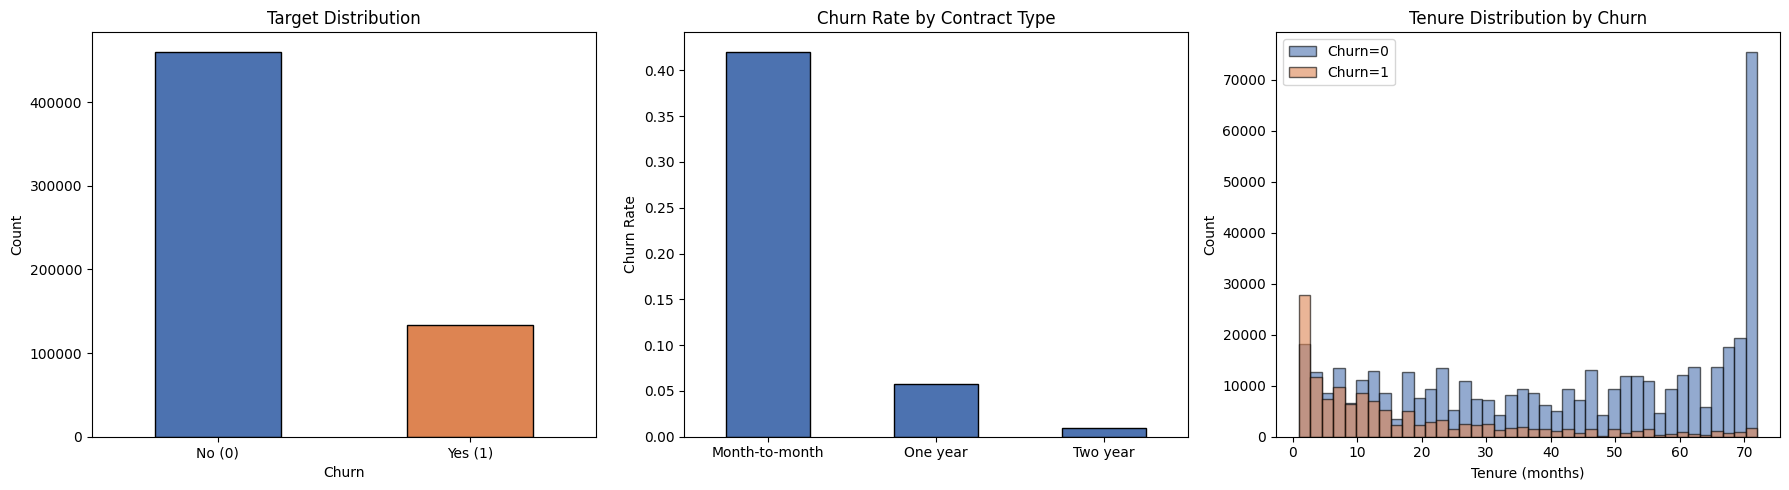

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Target distribution
train[CFG.target].value_counts().plot.bar(
    ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black'
)
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

# 3b. Churn rate by contract type
contract_churn = (
    train.groupby('Contract')[CFG.target]
    .mean()
    .sort_values(ascending=False)
)
contract_churn.plot.bar(
    ax=axes[1], color='#4C72B0', edgecolor='black'
)
axes[1].set_title("Churn Rate by Contract Type")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)

# 3c. Tenure distribution split by churn
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train[train[CFG.target] == label]['tenure']
    axes[2].hist(subset, bins=40, alpha=0.6, label=f"Churn={label}", color=color, edgecolor='black')
axes[2].set_title("Tenure Distribution by Churn")
axes[2].set_xlabel("Tenure (months)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()


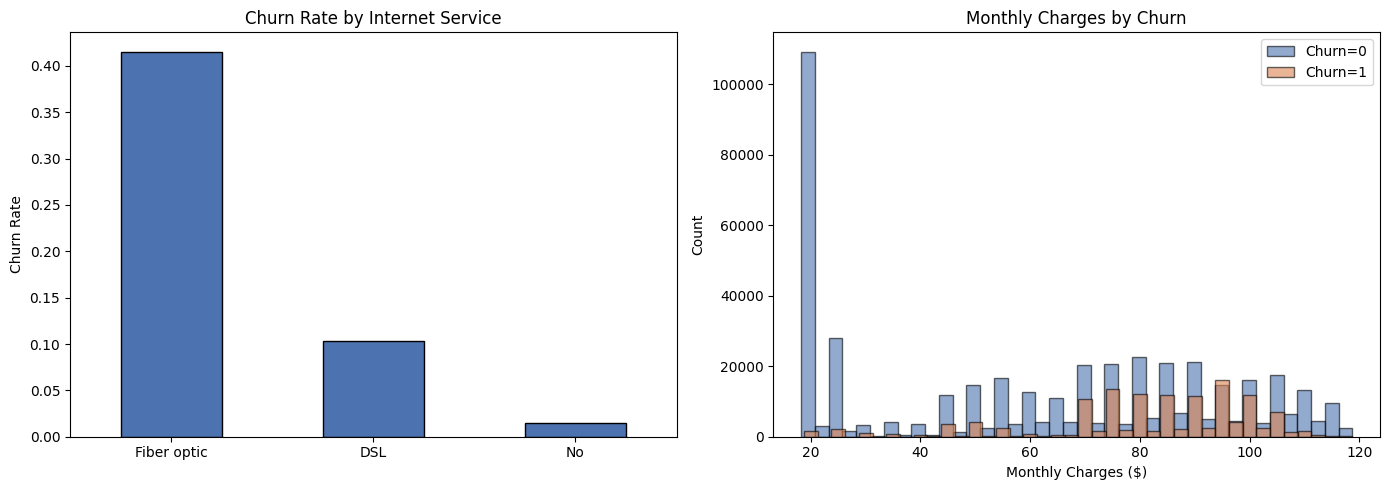

In [7]:
# Churn rate by internet service type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

internet_churn = (
    train.groupby('InternetService')[CFG.target]
    .mean()
    .sort_values(ascending=False)
)
internet_churn.plot.bar(
    ax=axes[0], color='#4C72B0', edgecolor='black'
)
axes[0].set_title("Churn Rate by Internet Service")
axes[0].set_ylabel("Churn Rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

# Monthly charges distribution by churn
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train[train[CFG.target] == label]['MonthlyCharges']
    axes[1].hist(subset, bins=40, alpha=0.6, label=f"Churn={label}", color=color, edgecolor='black')
axes[1].set_title("Monthly Charges by Churn")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


# 4. Methodology: Advanced Feature Engineering


The feature engineering phase focuses on the following areas:

1. **Financial ratios.** Normalizing charges against tenure helps detect billing anomalies and price sensitivity.
2. **Service counts.** Counting the number of active services per customer serves as a proxy for account stickiness.
3. **Lifecycle flags.** New customers and short-tenure customers exhibit different churn behavior than long-term users.
4. **Tenure binning.** Discretizing tenure into segments captures non-linear retention patterns.
5. **Categorical interactions.** Pairwise and triplet combinations of the most predictive categorical columns generate higher-order features.


In [8]:
def engineer_features(df):
    """Applies all feature transformations to the input dataframe."""

    # --- Financial ratios ---

    # Average monthly cost derived from total spend and tenure
    df['avg_monthly_from_total'] = df['TotalCharges'] / (df['tenure'] + 1)

    # Difference between the current bill and the historical average,
    # a positive value may indicate a recent price increase
    df['bill_shock'] = df['MonthlyCharges'] - df['avg_monthly_from_total']

    # Total spend per month of tenure
    df['charge_ratio'] = df['TotalCharges'] / (df['tenure'] + 1)

    # Tenure normalized by monthly charges
    df['tenure_scaled_charge'] = df['tenure'] / (df['MonthlyCharges'] + 1)

    # Ratio of total charges to monthly charges (approximates expected tenure)
    df['total_to_monthly'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)

    # Squared monthly charges to capture non-linear pricing effects
    df['monthly_charges_sq'] = df['MonthlyCharges'] ** 2

    # Log-transformed tenure
    df['log_tenure'] = np.log1p(df['tenure'])

    # Direct interaction between tenure and monthly charges
    df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']

    return df


In [9]:
def add_service_features(df):
    """Counts active services and creates segment-level summaries."""

    # Total number of active services (Yes, DSL, or Fiber optic count as active)
    service_cols = [
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df['service_count'] = 0
    for col in service_cols:
        if col in df.columns:
            df['service_count'] += df[col].apply(
                lambda x: 1 if x in ['Yes', 'DSL', 'Fiber optic'] else 0
            )

    # Count of security-related add-ons
    security_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    df['security_count'] = 0
    for col in security_cols:
        if col in df.columns:
            df['security_count'] += (df[col] == 'Yes').astype(int)

    # Count of streaming add-ons
    streaming_cols = ['StreamingTV', 'StreamingMovies']
    df['streaming_count'] = 0
    for col in streaming_cols:
        if col in df.columns:
            df['streaming_count'] += (df[col] == 'Yes').astype(int)

    return df


In [10]:
def add_lifecycle_features(df):
    """Flags for customer lifecycle stage and internet service type."""

    # Customers in their first month
    df['is_new_customer'] = (df['tenure'] <= 1).astype(int)

    # Customers within the first six months (higher risk window)
    df['is_short_tenure'] = (df['tenure'] <= 6).astype(int)

    # Tenure discretized into seven buckets
    df['tenure_bin'] = pd.cut(
        df['tenure'],
        bins=[0, 1, 6, 12, 24, 48, 72, 999],
        labels=[0, 1, 2, 3, 4, 5, 6]
    ).astype(int)

    # Fiber optic customers tend to churn at higher rates
    df['is_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

    # Customers without internet service behave differently
    df['no_internet'] = (df['InternetService'] == 'No').astype(int)

    return df


In [11]:
def add_interaction_features(df):
    """Generates pairwise and triplet categorical interactions."""

    # Contract type combined with tenure bucket
    df['contract_tenure'] = (
        df['Contract'].astype(str) + '_' + df['tenure_bin'].astype(str)
    )

    # All pairwise combinations of the top categorical columns
    for c1, c2 in combinations(CFG.top_cats, 2):
        df[f'{c1}_{c2}'] = df[c1].astype(str) + '_' + df[c2].astype(str)

    # Selected triplet interactions
    df['Contract_Internet_TechSupport'] = (
        df['Contract'].astype(str) + '_' +
        df['InternetService'].astype(str) + '_' +
        df['TechSupport'].astype(str)
    )
    df['Contract_Internet_Security'] = (
        df['Contract'].astype(str) + '_' +
        df['InternetService'].astype(str) + '_' +
        df['OnlineSecurity'].astype(str)
    )
    df['Contract_Payment_Billing'] = (
        df['Contract'].astype(str) + '_' +
        df['PaymentMethod'].astype(str) + '_' +
        df['PaperlessBilling'].astype(str)
    )

    return df


In [12]:
# Apply all feature engineering steps
train = engineer_features(train)
train = add_service_features(train)
train = add_lifecycle_features(train)
train = add_interaction_features(train)

test = engineer_features(test)
test = add_service_features(test)
test = add_lifecycle_features(test)
test = add_interaction_features(test)

print(f"Feature engineering complete. Total columns: {len(train.columns)}")


Feature engineering complete. Total columns: 57


# 5. Encoding Strategies and Leakage Prevention


Standard Mean Target Encoding can introduce data leakage if the encoding is computed on the full training set. To prevent this, we apply a **Nested K-Fold Encoding** strategy.

The mean target mapping $T_e$ for a category $C_i$ is:

$$ T_e(C_i) = \frac{\sum_{j=1}^{n} y_j \cdot \mathbb{1}(x_j = C_i)}{n_i} $$

where $y_j$ is the target value and $\mathbb{1}$ is the indicator function. The nested approach computes this mapping only on training folds, so no target information leaks into the validation sets.


In [13]:
def apply_nested_te(train_df, test_df, columns):
    """Cross-validated mean target encoding for the given columns."""
    tr_out = train_df.copy()
    te_out = test_df.copy()
    global_mean = tr_out[CFG.target].mean()

    for col in columns:
        if col not in tr_out.columns:
            continue

        # Compute the global mapping and apply it to the test set
        mapping = tr_out.groupby(col)[CFG.target].mean()
        te_out[f'{col}_te'] = te_out[col].map(mapping).fillna(global_mean)

        # For the training set, compute the mapping out-of-fold
        tr_out[f'{col}_te'] = np.nan
        skf = StratifiedKFold(
            n_splits=CFG.inner_folds, shuffle=True, random_state=CFG.seed
        )

        for tr_idx, val_idx in skf.split(tr_out, tr_out[CFG.target]):
            fold_mapping = tr_out.iloc[tr_idx].groupby(col)[CFG.target].mean()
            tr_out.loc[
                tr_out.index[val_idx], f'{col}_te'
            ] = tr_out.iloc[val_idx][col].map(fold_mapping)

        tr_out[f'{col}_te'] = tr_out[f'{col}_te'].fillna(global_mean)

    return tr_out, te_out


In [14]:
# Identify categorical columns and build the target-encoding list
cat_features = [c for c in train.columns if train[c].dtype == 'object']

te_features = (
    [c for c in train.columns if '_' in c and c in cat_features]
    + CFG.top_cats
)

# Include the new interaction columns if they are categorical
for col in ['contract_tenure', 'Contract_Internet_Security', 'Contract_Payment_Billing']:
    if col in cat_features and col not in te_features:
        te_features.append(col)

print(f"Columns to target-encode: {len(te_features)}")

train, test = apply_nested_te(train, test, te_features)


Columns to target-encode: 25


In [15]:
# Label-encode all remaining object columns so XGBoost can consume them
for col in cat_features:
    le = LabelEncoder()

    train[col] = train[col].astype(str)
    test[col]  = test[col].astype(str)

    combined = pd.concat([train[col], test[col]])
    le.fit(combined)

    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

print(f"Encoding complete. Final feature count: {len(train.columns)}")


Encoding complete. Final feature count: 82


# 6. Model Architecture: Multi-Seed XGBoost


The model uses a single XGBoost configuration trained across multiple random seeds. Averaging over several seeds reduces the variance of the final predictions without introducing the noise that comes from blending fundamentally different model types.

Each seed produces its own set of out-of-fold (OOF) and test predictions through stratified K-fold cross-validation. The final output is the element-wise mean of all seed runs.


In [16]:
# Prepare the feature matrix and target vector
X      = train.drop(columns=[CFG.target, 'id'])
y      = train[CFG.target]
X_test = test.drop(columns=['id'])

# Store test IDs for submission
test_ids = test['id'].values

# Class imbalance ratio used by XGBoost to weight the positive class
scale_weight = (y == 0).sum() / (y == 1).sum()

print(f"X shape:      {X.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive ratio: {y.mean():.4f}")
print(f"scale_pos_weight: {scale_weight:.4f}")


X shape:      (594194, 80)
X_test shape: (254655, 80)
Positive ratio: 0.2252
scale_pos_weight: 3.4403


In [17]:
def train_xgb(X, y, X_test, seed, verbose=False):
    """Trains XGBoost with stratified K-fold CV and returns OOF and test predictions."""
    oof   = np.zeros(len(X))
    preds = np.zeros(len(X_test))
    fold_scores = []

    skf = StratifiedKFold(
        n_splits=CFG.n_folds, shuffle=True, random_state=seed
    )

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

        model = xgb.XGBClassifier(
            n_estimators       = 15000,
            learning_rate      = 0.005,
            max_depth          = 5,
            subsample          = 0.8,
            colsample_bytree   = 0.3,
            min_child_weight   = 6,
            reg_alpha          = 3.5,
            reg_lambda         = 1.3,
            gamma              = 0.8,
            random_state       = seed,
            tree_method        = 'hist',
            device             = 'cuda' if CFG.gpu else 'cpu',
            scale_pos_weight   = scale_weight,
            early_stopping_rounds = 500,
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=0
        )

        val_preds = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_preds
        preds += model.predict_proba(X_test)[:, 1] / CFG.n_folds

        fold_scores.append(roc_auc_score(y_val, val_preds))

    overall_auc = roc_auc_score(y, oof)

    if verbose:
        print(f"  Seed {seed:>5d}  |  CV AUC: {overall_auc:.6f}  |  fold std: {np.std(fold_scores):.6f}")

    return oof, preds, overall_auc


In [18]:
# Train across all seeds and collect predictions
print("Multi-seed XGBoost training")
print("-" * 55)

all_oof   = []
all_preds = []
all_aucs  = []

for seed in CFG.seeds:
    oof_s, preds_s, auc_s = train_xgb(X, y, X_test, seed, verbose=True)
    all_oof.append(oof_s)
    all_preds.append(preds_s)
    all_aucs.append(auc_s)

# Average across seeds
oof_phase1   = np.mean(all_oof, axis=0)
preds_phase1 = np.mean(all_preds, axis=0)
phase1_auc   = roc_auc_score(y, oof_phase1)

print("-" * 55)
print(f"Averaged CV AUC: {phase1_auc:.6f}")


Multi-seed XGBoost training
-------------------------------------------------------
  Seed    42  |  CV AUC: 0.916360  |  fold std: 0.001229
  Seed  2024  |  CV AUC: 0.916374  |  fold std: 0.000905
  Seed  2025  |  CV AUC: 0.916405  |  fold std: 0.000999
  Seed     7  |  CV AUC: 0.916396  |  fold std: 0.001215
  Seed    13  |  CV AUC: 0.916381  |  fold std: 0.000866
-------------------------------------------------------
Averaged CV AUC: 0.916530


# 7. Pseudo Labeling


Pseudo labeling is a semi-supervised technique. High-confidence predictions on the test set are treated as ground truth and appended to the training data. The model is then retrained on this larger dataset.

The procedure is as follows:

1. Train on the labeled data and predict on the test set.
2. Select test rows where $P(\text{churn}) > \tau$ or $P(\text{churn}) < 1 - \tau$.
3. Assign hard labels (0 or 1) to these rows and add them to the training set.
4. Retrain and repeat.

A high threshold ($\tau = 0.985$) ensures that only very confident predictions are included, which limits the impact of incorrect labels.


In [19]:
current_preds = preds_phase1.copy()

for pl_round in range(CFG.pl_rounds):
    print(f"Pseudo labeling round {pl_round + 1}/{CFG.pl_rounds}")
    print("-" * 55)

    # Identify high-confidence rows
    mask_pos = current_preds >= CFG.pl_threshold
    mask_neg = current_preds <= (1.0 - CFG.pl_threshold)
    mask     = mask_pos | mask_neg

    n_total = mask.sum()
    n_pos   = mask_pos.sum()
    n_neg   = mask_neg.sum()

    print(f"  Pseudo-labeled samples: {n_total} ({n_pos} positive, {n_neg} negative)")

    if n_total < 100:
        print("  Too few confident samples. Skipping this round.")
        continue

    # Build the pseudo-labeled rows
    X_pseudo = X_test[mask].copy()
    y_pseudo = (current_preds[mask] >= 0.5).astype(int)

    # Concatenate with the original training data
    X_aug = pd.concat([X, X_pseudo], axis=0).reset_index(drop=True)
    y_aug = pd.concat([y, pd.Series(y_pseudo)], axis=0).reset_index(drop=True)

    print(f"  Augmented training size: {len(X_aug)} (original {len(X)} + pseudo {n_total})")

    # Retrain multi-seed ensemble on the augmented data
    round_preds = []
    round_aucs  = []

    for seed in CFG.seeds:
        _, preds_s, auc_s = train_xgb(X_aug, y_aug, X_test, seed, verbose=True)
        round_preds.append(preds_s)
        round_aucs.append(auc_s)

    current_preds = np.mean(round_preds, axis=0)
    print(f"  Round {pl_round + 1} mean CV AUC (augmented): {np.mean(round_aucs):.6f}")
    print()

final_preds = current_preds

print("Pseudo labeling complete.")


Pseudo labeling round 1/2
-------------------------------------------------------
  Pseudo-labeled samples: 58522 (1204 positive, 57318 negative)
  Augmented training size: 652716 (original 594194 + pseudo 58522)
  Seed    42  |  CV AUC: 0.926281  |  fold std: 0.001086
  Seed  2024  |  CV AUC: 0.926305  |  fold std: 0.000617
  Seed  2025  |  CV AUC: 0.926303  |  fold std: 0.000953
  Seed     7  |  CV AUC: 0.926315  |  fold std: 0.000807
  Seed    13  |  CV AUC: 0.926364  |  fold std: 0.001342
  Round 1 mean CV AUC (augmented): 0.926314

Pseudo labeling round 2/2
-------------------------------------------------------
  Pseudo-labeled samples: 89139 (4029 positive, 85110 negative)
  Augmented training size: 683333 (original 594194 + pseudo 89139)
  Seed    42  |  CV AUC: 0.931484  |  fold std: 0.000918
  Seed  2024  |  CV AUC: 0.931490  |  fold std: 0.000753
  Seed  2025  |  CV AUC: 0.931481  |  fold std: 0.000615
  Seed     7  |  CV AUC: 0.931448  |  fold std: 0.000904
  Seed    13  | 

# 8. Evaluation and Statistical Analysis


This section compares the prediction distribution before and after pseudo labeling and reports summary statistics for the final test predictions.


In [20]:
print(f"Phase 1 (multi-seed, no PL) CV AUC: {phase1_auc:.6f}")
print()
print("Final prediction statistics:")
print(f"  mean: {final_preds.mean():.6f}")
print(f"  std:  {final_preds.std():.6f}")
print(f"  min:  {final_preds.min():.6f}")
print(f"  max:  {final_preds.max():.6f}")


Phase 1 (multi-seed, no PL) CV AUC: 0.916530

Final prediction statistics:
  mean: 0.364594
  std:  0.412058
  min:  0.000003
  max:  0.999857


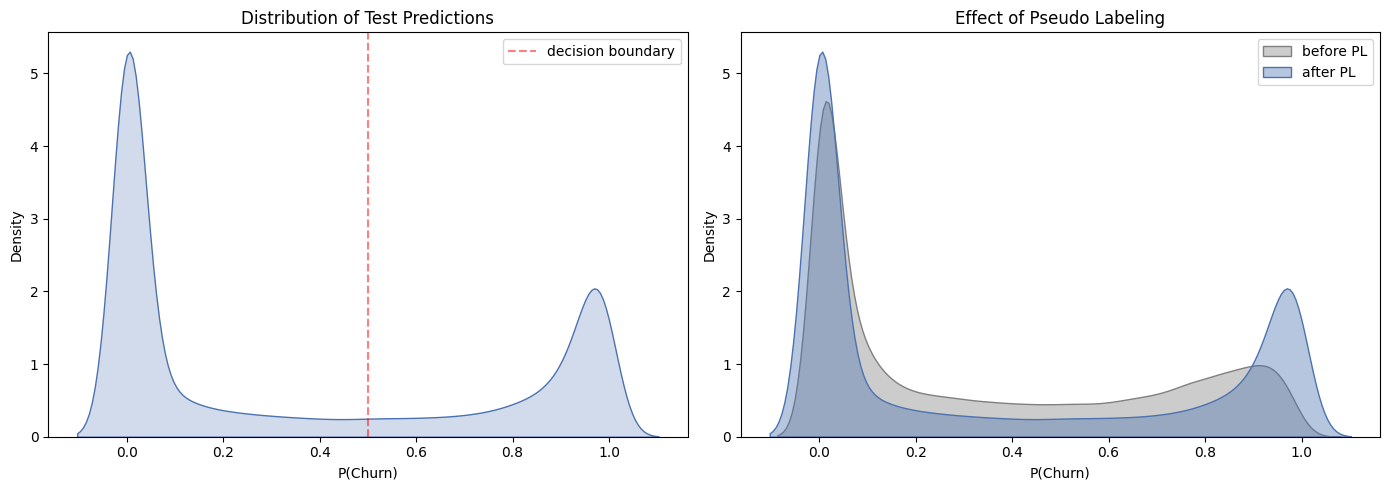

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of final test predictions
sns.kdeplot(final_preds, fill=True, color='#4C72B0', ax=axes[0])
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='decision boundary')
axes[0].set_title("Distribution of Test Predictions")
axes[0].set_xlabel("P(Churn)")
axes[0].legend()

# Before vs after pseudo labeling
sns.kdeplot(preds_phase1,  fill=True, alpha=0.4, color='gray',    label='before PL', ax=axes[1])
sns.kdeplot(final_preds,   fill=True, alpha=0.4, color='#4C72B0', label='after PL',  ax=axes[1])
axes[1].set_title("Effect of Pseudo Labeling")
axes[1].set_xlabel("P(Churn)")
axes[1].legend()

plt.tight_layout()
plt.show()


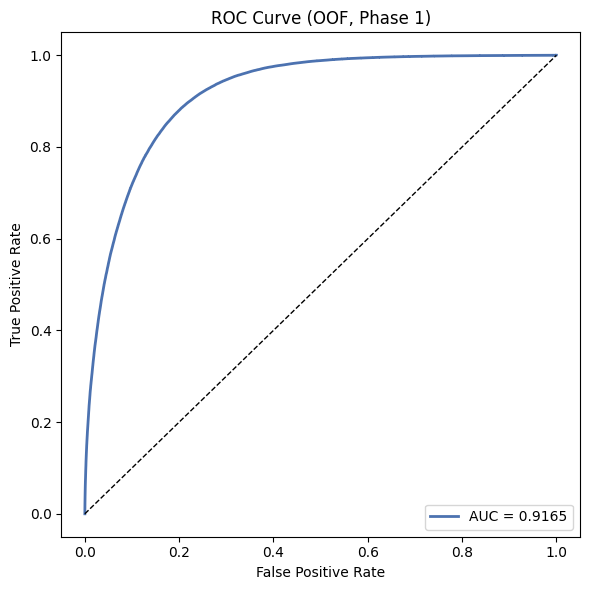

In [22]:
# ROC curve on the Phase 1 OOF predictions
fpr, tpr, _ = roc_curve(y, oof_phase1)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {phase1_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OOF, Phase 1)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# 9. Inference and Results Documentation


The final predictions are written to `submission.csv` for upload to the competition leaderboard.


In [23]:
sub_template = os.path.join(base_dir, 'sample_submission.csv')

if os.path.exists(sub_template):
    submission = pd.read_csv(sub_template)
    submission['Churn'] = final_preds
else:
    submission = pd.DataFrame({
        'id': test_ids,
        'Churn': final_preds
    })

submission.to_csv('submission.csv', index=False)

print(f"Submission shape: {submission.shape}")
submission.head(10)


Submission shape: (254655, 2)


,id,Churn
0,594194,0.045839
1,594195,0.000017
2,594196,0.238782
3,594197,0.000066
4,594198,0.842875
5,594199,0.660413
6,594200,0.997376
7,594201,0.000168
8,594202,0.051317
9,594203,0.880966


# 10. Conclusion and Results Summary


This notebook implemented the following pipeline:

1. **Data augmentation.** Combined synthetic competition data with historical Telco records.
2. **Feature engineering.** Created financial ratios, service counts, lifecycle flags, tenure bins, and categorical interaction features.
3. **Leakage-free encoding.** Applied nested K-Fold mean target encoding.
4. **Multi-seed XGBoost.** Trained XGBoost across five random seeds and averaged predictions to reduce variance.
5. **Pseudo labeling.** Used high-confidence test predictions as additional training data over two iterations.

---

**Citation:**
Will Cukierski. Predict Customer Churn. https://kaggle.com/competitions/playground-series-s6e3, 2024. Kaggle.
